# Scenario 3 – Random Forest
**Roll Number:** 24BAD002  
**Name:** Abhishek J


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print(f"Roll Number: 24BAD002")
print(f"Name: Abhishek J")


Roll Number: 24BAD002
Name: Abhishek J


## 1. Load Dataset

In [2]:
df = pd.read_csv("income_random_forest.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass Distribution:")
print(df['Income'].value_counts())


Shape: (120, 5)
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1

Class Distribution:
Income
0    80
1    40
Name: count, dtype: int64


## 2. Prepare Features

In [3]:
X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Train: 96, Test: 24


## 3. Train Random Forest & Tune n_estimators

In [4]:
n_estimators_range = [10, 20, 50, 100, 150, 200]
acc_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    acc_scores.append(acc)
    print(f"n_estimators={n:4d} -> Accuracy: {acc:.4f}")

best_n = n_estimators_range[np.argmax(acc_scores)]
print(f"\nBest n_estimators: {best_n}")


n_estimators=  10 -> Accuracy: 1.0000
n_estimators=  20 -> Accuracy: 1.0000
n_estimators=  50 -> Accuracy: 1.0000
n_estimators= 100 -> Accuracy: 1.0000
n_estimators= 150 -> Accuracy: 1.0000
n_estimators= 200 -> Accuracy: 1.0000

Best n_estimators: 10


## 4. Evaluate Best Model

In [5]:
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Best Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['<=50K', '>50K']))


Best Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00        16
        >50K       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



## 5. Visualization – Feature Importance & Accuracy vs Trees

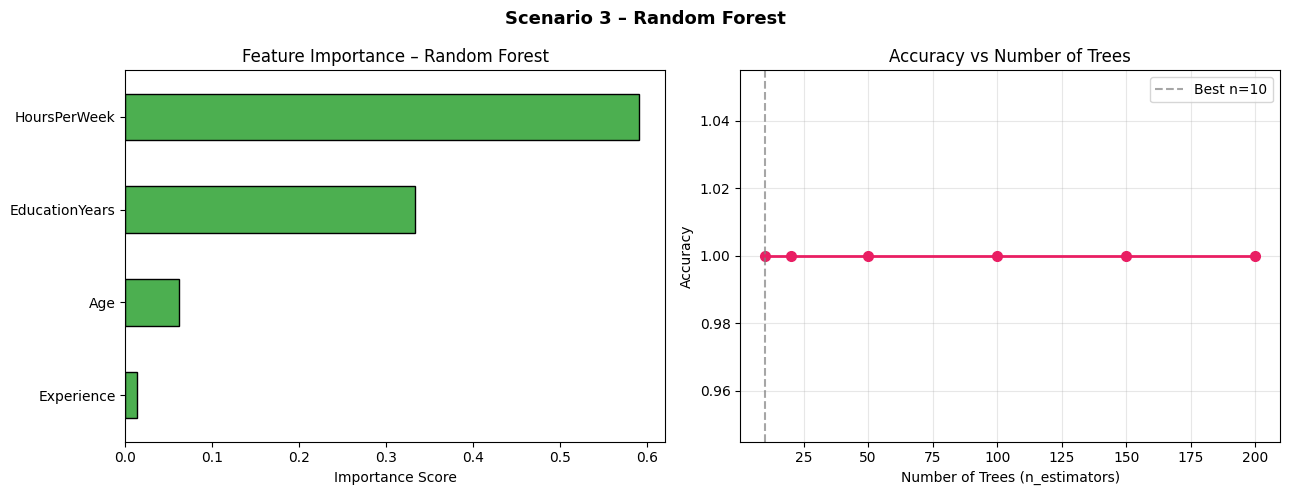

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Scenario 3 – Random Forest", fontsize=13, fontweight='bold')

# Feature Importance
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[0], color='#4CAF50', edgecolor='black')
axes[0].set_title("Feature Importance – Random Forest")
axes[0].set_xlabel("Importance Score")

# Accuracy vs n_estimators
axes[1].plot(n_estimators_range, acc_scores, marker='o', color='#E91E63', lw=2, ms=7)
axes[1].axvline(best_n, color='gray', linestyle='--', alpha=0.7, label=f'Best n={best_n}')
axes[1].set_xlabel("Number of Trees (n_estimators)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Number of Trees")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scenario3_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Summary

In [7]:
print(f"  Best n_estimators      : {best_n}")
print(f"  Best Accuracy          : {rf_acc:.4f}")
print(f"  Top Feature            : {feat_imp.idxmax()}")



  Best n_estimators      : 10
  Best Accuracy          : 1.0000
  Top Feature            : HoursPerWeek
